1.   **Word2Vec on user-written feedback**
2.   **RNN to model sentence evolution**
3.   **Supervised ML → dropout prediction**
4.   **Unsupervised ML → behavioral personas**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## **DATA CLEANING**

In [ ]:
df=pd.read_csv("/content/early_dropout_risk_detection_10000.csv")

In [ ]:
df.head(2)

,user_id,course_name,country,device_type,avg_session_time_min,days_active_last_30,videos_watched,assignments_completed,activity_level,feedback_text,dropout
0,1,Web Development,India,mobile,165,27,44,6,low,i stopped understanding after few lessons,0
1,2,Cyber Security,USA,mobile,31,17,115,13,high,not enough support,0


In [ ]:
df.isnull().sum()

,0
user_id,0
course_name,1657
country,1656
device_type,2529
avg_session_time_min,0
days_active_last_30,0
videos_watched,0
assignments_completed,0
activity_level,2492
feedback_text,910


In [ ]:
df['course_name']=df['course_name'].fillna('not available')
df['country']=df['country'].fillna('not available')
df['device_type']=df['device_type'].fillna('not available')
df['activity_level']=df['activity_level'].fillna('not available')
df['feedback_text']=df['feedback_text'].fillna('not available')

In [ ]:
df.head()

,user_id,course_name,country,device_type,avg_session_time_min,days_active_last_30,videos_watched,assignments_completed,activity_level,feedback_text,dropout
0,1,Web Development,India,mobile,165,27,44,6,low,i stopped understanding after few lessons,0
1,2,Cyber Security,USA,mobile,31,17,115,13,high,not enough support,0
2,3,AI,Canada,not available,17,20,64,17,medium,not enough support,1
3,4,Cyber Security,USA,desktop,137,24,2,29,medium,platform is good but i am losing interest,1
4,5,Cyber Security,UK,desktop,109,0,95,23,medium,too fast pace for beginners,1


In [ ]:
df.isnull().sum()

,0
user_id,0
course_name,0
country,0
device_type,0
avg_session_time_min,0
days_active_last_30,0
videos_watched,0
assignments_completed,0
activity_level,0
feedback_text,0


## **NLP**

In [ ]:
df.head(2)

,user_id,course_name,country,device_type,avg_session_time_min,days_active_last_30,videos_watched,assignments_completed,activity_level,feedback_text,dropout
0,1,Web Development,India,mobile,165,27,44,6,low,i stopped understanding after few lessons,0
1,2,Cyber Security,USA,mobile,31,17,115,13,high,not enough support,0


In [ ]:
!pip install nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from sklearn.feature_extraction.text import TfidfVectorizer
encoder = OneHotEncoder(drop='first', handle_unknown="ignore")
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
tfidf=TfidfVectorizer(stop_words='english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
tfidf_course=encoder.fit_transform(df[['course_name']]).toarray()
tfidf_country = encoder.fit_transform(df[['country']]).toarray()
tfidf_device_type = encoder.fit_transform(df[['device_type']]).toarray()
tfidf_activity_level = le.fit_transform(df['activity_level']).reshape(-1, 1)

In [ ]:
df['new_course']=list(tfidf_course)
df['new_country']=list(tfidf_country)
df['new_device_type']=list(tfidf_device_type)
df['new_activity_level']=list(tfidf_activity_level)

In [ ]:
import re
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
corpus = []

for sentence in df['feedback_text']:
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)
    sentence = sentence.lower()
    words = sentence.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    corpus.append(" ".join(words))   # MUST be string

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer()

tokenizer.fit_on_texts(corpus)
total_words=len(tokenizer.word_index)+1

tok=[]

for sent in corpus:
  tokinized=tokenizer.texts_to_sequences([sent])[0]
  for i in range(1, len(tokinized)):
        tok.append(tokinized[:i+1])

pd_seq=pad_sequences(tok, maxlen=15)
pd_seq = np.array(pd_seq)

from tensorflow.keras.layers import Embedding, Dense, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences

x = pd_seq[:, :-1]
y = pd_seq[:, -1]

model = Sequential()
model.add(Embedding(input_dim=total_words, output_dim=10, input_length=x.shape[1]))
model.add(LSTM(16))
model.add(Dense(total_words, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x, y, epochs=10, batch_size=32)

root = "i was enjoying"
extras = 2

for _ in range(extras):
    new_text = tokenizer.texts_to_sequences([root])[0]
    pad_sent = pad_sequences([new_text], maxlen=x.shape[1], padding="pre")
    pred = model.predict(pad_sent, verbose=0).argmax()
    root += " " + tokenizer.index_word[pred]

print(root)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


714/714 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.2747 - loss: 2.8545
Epoch 2/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 1.0000 - loss: 0.5476
Epoch 3/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 1.0000 - loss: 0.1196
Epoch 4/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 1.0000 - loss: 0.0495
Epoch 5/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 1.0000 - loss: 0.0262
Epoch 6/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 1.0000 - loss: 0.0155
Epoch 7/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 1.0000 - loss: 0.0097
Epoch 8/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 1.0000 - loss: 0.0063
Epoch 9/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 1.0000 - loss: 0.0042
Epoch 10/10
714/714 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 1.0000 - loss: 0.0029
i was enjoying good motiv


## **SUPERVISED ML**

In [ ]:
x_nc=np.stack(df['new_course'].values)
x_cn=np.stack(df['new_country'].values)
x_dt=np.stack(df['new_device_type'].values)
x_al=np.stack(df['new_activity_level'].values)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english')
x_ft=tfidf.fit_transform(df['feedback_text'].values).toarray()

x_direct=df[['assignments_completed', 'videos_watched', 'days_active_last_30', 'avg_session_time_min']].values
x=np.concatenate([x_nc, x_cn, x_dt, x_al, x_ft, x_direct], axis=1)
y=df['dropout']

In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [ ]:
std=StandardScaler()
x_train_std=std.fit_transform(x_train)
x_test_std=std.transform(x_test)

In [ ]:
kf=StratifiedKFold(n_splits=5)
y_pred_train=cross_val_predict(model, x_train_std, y_train, cv=kf)

In [ ]:
model.fit(x_train_std, y_train)
y_pred_test=model.predict(x_test_std)
print(y_pred_test)

[0 1 0 ... 0 0 0]


In [ ]:
#EVALUATE
acc_train=accuracy_score(y_train,y_pred_train)
acc_test=accuracy_score(y_test,y_pred_test)

prec_sc_train=precision_score(y_train,y_pred_train)
prec_cv_test=precision_score(y_test,y_pred_test)

recall_train=recall_score(y_train,y_pred_train)
recall_test=recall_score(y_test,y_pred_test)

clas_train=classification_report(y_train,y_pred_train)
clas_test=classification_report(y_test,y_pred_test)

conf_train=confusion_matrix(y_train,y_pred_train)
conf_test=confusion_matrix(y_test,y_pred_test)

print(acc_train)
print(acc_test)
print(prec_sc_train)
print(prec_cv_test)
print(recall_train)
print(recall_test)
print(clas_train)
print(clas_test)
print(conf_train)
print(conf_test)

0.5011428571428571
0.5103333333333333
0.35525543159130946
0.3406052076002815
0.4828411811652035
0.4763779527559055
              precision    recall  f1-score   support

           0       0.64      0.51      0.57      4494
           1       0.36      0.48      0.41      2506

    accuracy                           0.50      7000
   macro avg       0.50      0.50      0.49      7000
weighted avg       0.54      0.50      0.51      7000

              precision    recall  f1-score   support

           0       0.66      0.53      0.59      1984
           1       0.34      0.48      0.40      1016

    accuracy                           0.51      3000
   macro avg       0.50      0.50      0.49      3000
weighted avg       0.55      0.51      0.52      3000

[[2298 2196]
 [1296 1210]]
[[1047  937]
 [ 532  484]]


## **UNSUPERVISED ML**

In [ ]:
df.head(2)

,user_id,course_name,country,device_type,avg_session_time_min,days_active_last_30,videos_watched,assignments_completed,activity_level,feedback_text,dropout,new_course,new_country,new_device_type,new_activity_level
0,1,Web Development,India,mobile,165,27,44,6,low,i stopped understanding after few lessons,0,"[0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 1.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",[1]
1,2,Cyber Security,USA,mobile,31,17,115,13,high,not enough support,0,"[1.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 1.0, 0.0]","[1.0, 0.0, 0.0]",[0]


In [ ]:
astm=df[['avg_session_time_min']]
dal=df[['days_active_last_30']]
vw=df[['videos_watched']]
ac=df[['assignments_completed']]

x_new=np.concatenate([x_nc,x_cn,x_al,astm,dal,vw,ac], axis=1)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

model = KMeans(n_clusters=5, init='k-means++')

sc=StandardScaler()
x_new_std=sc.fit_transform(x_new)

labels=model.fit_predict(x_new_std)
df['clusters']=labels

y_pred=model.predict(x_new_std)
print(y_pred)

sc=silhouette_score(x_new_std, y_pred)
print(sc)

[4 2 2 ... 1 1 4]
0.17926892277468745


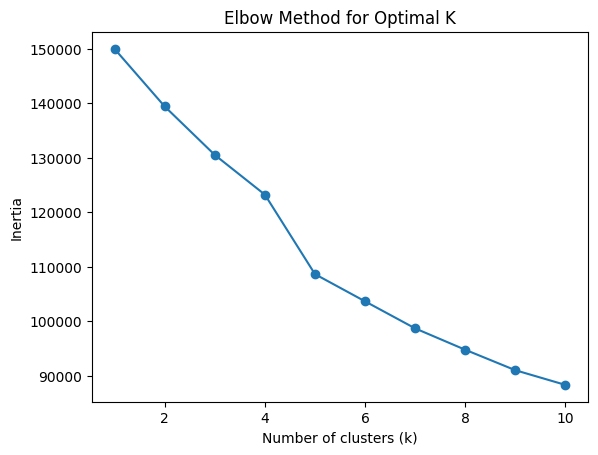

In [ ]:
K_values = range(1, 11)
inertias = []

for k in K_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(x_new_std)
    inertias.append(model.inertia_)

# PLOT ELBOW
plt.plot(K_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [ ]:
df.head(2)

,user_id,course_name,country,device_type,avg_session_time_min,days_active_last_30,videos_watched,assignments_completed,activity_level,feedback_text,dropout,new_course,new_country,new_device_type,new_activity_level,clusters
0,1,Web Development,India,mobile,165,27,44,6,low,i stopped understanding after few lessons,0,"[0.0, 0.0, 0.0, 1.0, 0.0]","[0.0, 1.0, 0.0, 0.0, 0.0]","[1.0, 0.0, 0.0]",[1],4
1,2,Cyber Security,USA,mobile,31,17,115,13,high,not enough support,0,"[1.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.0, 0.0, 1.0, 0.0]","[1.0, 0.0, 0.0]",[0],2


In [ ]:
cluster_counts = df["clusters"].value_counts().sort_index()
print(cluster_counts)

clusters
0    1657
1    1692
2    3314
3    1665
4    1672
Name: count, dtype: int64


In [ ]:
cluster_percentage = df["clusters"].value_counts(normalize=True) * 100
print(cluster_percentage)

clusters
2    33.14
1    16.92
4    16.72
3    16.65
0    16.57
Name: proportion, dtype: float64


In [ ]:
dropout_rate = (df.groupby("clusters")["dropout"].mean() * 100)

print(dropout_rate)

clusters
0    35.184068
1    35.992908
2    35.576343
3    34.294294
4    34.688995
Name: dropout, dtype: float64


In [ ]:
df.groupby("clusters")[["avg_session_time_min", "days_active_last_30", "videos_watched", "assignments_completed"]].mean()

,avg_session_time_min,days_active_last_30,videos_watched,assignments_completed
clusters,,,,
0,91.164756,14.582981,59.853349,14.838865
1,89.938534,15.227541,58.252955,14.584515
2,89.901629,14.490042,59.110742,14.317743
3,89.921321,14.780180,60.249249,14.587988
4,89.772727,14.627990,59.254187,14.626794


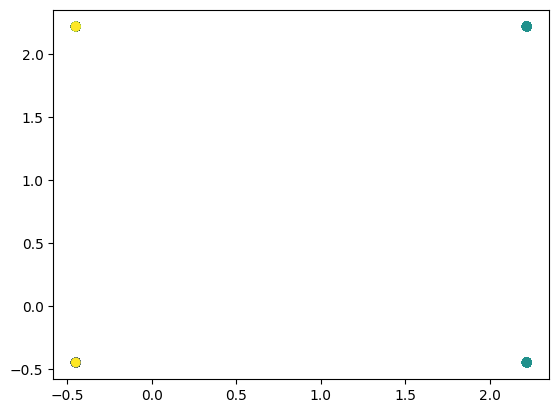

In [ ]:
plt.scatter(x_new_std[ :, 0], x_new_std[ :, 6], c=labels)